In [1]:
!pip install -q torch torchvision tqdm scikit-learn matplotlib


In [2]:
import os

# ⭐ Kaggle 인증용 환경 변수
os.environ["KAGGLE_USERNAME"] = "kohwoohyun123"
os.environ["KAGGLE_KEY"] = "KGAT_c2eae3dc90d508dfc8537b5e60257e47"


In [3]:
!pip install -q kaggle


In [4]:
!kaggle datasets list | head


ref                                                                title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                                Chocolate Sales                                      468320  2026-01-04 14:23:35.490000              0        122  1.0              
vishardmehta/indian-engineering-college-placement-dataset          Indian Engineering College Placement Dataset         137603  2026-01-24 15:23:40.150000              0         29  1.0              
rockyt07/social-media-user-analysis                                Social Media User Analysis                        247842357  2026-01-14 02:28:41.970000              0        124  1.0              


In [5]:
!kaggle datasets download -d ipythonx/mvtec-ad
!unzip -q mvtec-ad.zip


Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
mvtec-ad.zip: Skipping, found more recently modified local copy (use --force to force download)
replace bottle/ground_truth/broken_large/000_mask.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
!ls


bottle	 carpet    leather	mvtec-ad.zip  sample_data  toothbrush  zipper
cable	 grid	   license.txt	pill	      screw	   transistor
capsule  hazelnut  metal_nut	readme.txt    tile	   wood


In [7]:
import os
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.neighbors import NearestNeighbors


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [9]:
class MVTecDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        if split == "train":
            good_dir = os.path.join(root, "train", "good")
            for img in os.listdir(good_dir):
                self.image_paths.append(os.path.join(good_dir, img))
                self.labels.append(0)  # 정상만
        else:
            test_dir = os.path.join(root, "test")
            for defect_type in os.listdir(test_dir):
                defect_path = os.path.join(test_dir, defect_type)
                for img in os.listdir(defect_path):
                    self.image_paths.append(os.path.join(defect_path, img))
                    self.labels.append(0 if defect_type == "good" else 1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


In [10]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])


In [11]:
DATA_DIR = "/content/bottle"

train_ds = MVTecDataset(DATA_DIR, split="train", transform=transform)
test_ds  = MVTecDataset(DATA_DIR, split="test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

print(len(train_ds), len(test_ds))


209 83


In [12]:
model = models.resnet18(pretrained=True)
model.eval().to(device)

features = []

def hook(module, input, output):
    features.append(output)

model.layer3.register_forward_hook(hook)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
memory_bank = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        features.clear()
        _ = model(x)

        feat = features[0]
        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1)
        memory_bank.append(feat.cpu().numpy())

memory_bank = np.concatenate(memory_bank, axis=0)
print("Memory bank shape:", memory_bank.shape)


Memory bank shape: (209, 256)


In [14]:
nn_model = NearestNeighbors(n_neighbors=1)
nn_model.fit(memory_bank)


NearestNeighbors(n_neighbors=1)

In [15]:
scores = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        features.clear()
        _ = model(x)

        feat = features[0]
        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1).cpu().numpy()

        dist, _ = nn_model.kneighbors(feat)
        scores.append(dist[0][0])
        labels.append(y.item())


In [16]:
scores = np.array(scores)
labels = np.array(labels)


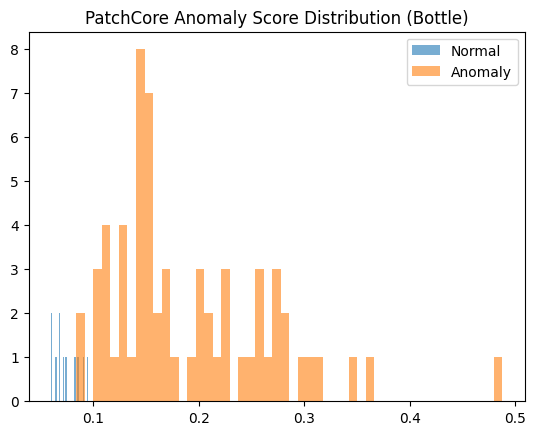

In [17]:
import matplotlib.pyplot as plt

plt.hist(scores[labels == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[labels == 1], bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.title("PatchCore Anomaly Score Distribution (Bottle)")
plt.show()


In [18]:
# layer별 feature 저장소
features_map = {}

def make_hook(name):
    def hook(module, input, output):
        features_map[name] = output
    return hook

# 기존 hook 유지 + 추가 hook
model.layer2.register_forward_hook(make_hook("layer2"))
model.layer3.register_forward_hook(make_hook("layer3"))


In [19]:
def build_memory_bank(dataloader, layer_name):
    bank = []

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            features_map.clear()
            _ = model(x)

            feat = features_map[layer_name]   # [1, C, H, W]
            feat = F.adaptive_avg_pool2d(feat, (1, 1))
            feat = feat.view(feat.size(0), -1)
            bank.append(feat.cpu().numpy())

    return np.concatenate(bank, axis=0)


In [20]:
mem_l2 = build_memory_bank(train_loader, "layer2")
mem_l3 = build_memory_bank(train_loader, "layer3")

# layer2 + layer3 결합
mem_l23 = np.concatenate([mem_l2, mem_l3], axis=1)

print(mem_l2.shape, mem_l3.shape, mem_l23.shape)


(209, 128) (209, 256) (209, 384)


In [21]:
nn_l2  = NearestNeighbors(n_neighbors=1).fit(mem_l2)
nn_l3  = NearestNeighbors(n_neighbors=1).fit(mem_l3)
nn_l23 = NearestNeighbors(n_neighbors=1).fit(mem_l23)


In [22]:
def compute_anomaly_map(x, layer_names, nn_model, model):
    feats = []
    feature_maps = {}

    hooks = []
    for name in layer_names:
        layer = dict(model.named_modules())[name]
        hooks.append(
            layer.register_forward_hook(
                lambda m, i, o, name=name: feature_maps.setdefault(name, o)
            )
        )

    with torch.no_grad():
        _ = model(x)

    for h in hooks:
        h.remove()

    # 기준 해상도: 가장 작은 H, W
    target_h = min(feature_maps[name].shape[2] for name in layer_names)
    target_w = min(feature_maps[name].shape[3] for name in layer_names)

    for name in layer_names:
        f = feature_maps[name]
        if f.shape[2] != target_h or f.shape[3] != target_w:
            f = F.interpolate(f, size=(target_h, target_w),
                              mode="bilinear", align_corners=False)
        feats.append(f)

    # concat
    feat = torch.cat(feats, dim=1)

    # patch 단위로 reshape
    B, C, H, W = feat.shape
    feat = feat.permute(0, 2, 3, 1).reshape(-1, C)
    feat = feat.cpu().numpy()

    dist, _ = nn_model.kneighbors(feat)
    anomaly_map = dist.reshape(H, W)

    return anomaly_map


In [23]:
idx = 10   # anomaly 이미지로 바꿔도 됨
x, y = test_ds[idx]
x = x.unsqueeze(0).to(device)


In [24]:
map_l2  = compute_anomaly_map(x, ["layer2"], nn_l2, model)
map_l3  = compute_anomaly_map(x, ["layer3"], nn_l3, model)
map_l23 = compute_anomaly_map(x, ["layer2", "layer3"], nn_l23, model)


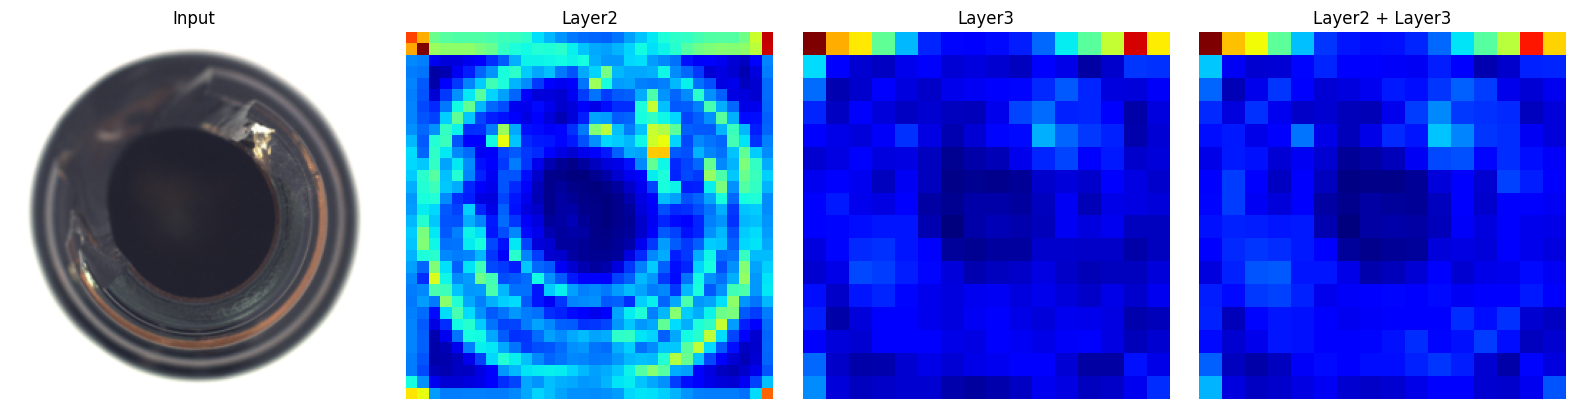

In [25]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(x[0].permute(1, 2, 0).cpu())
axs[0].set_title("Input")
axs[0].axis("off")

axs[1].imshow(map_l2, cmap="jet")
axs[1].set_title("Layer2")
axs[1].axis("off")

axs[2].imshow(map_l3, cmap="jet")
axs[2].set_title("Layer3")
axs[2].axis("off")

axs[3].imshow(map_l23, cmap="jet")
axs[3].set_title("Layer2 + Layer3")
axs[3].axis("off")

plt.tight_layout()
plt.show()


In [26]:
# =========================
# Histogram 비교용 score 계산
# =========================

def compute_image_scores(test_loader, layer_names, nn_model, model):
    scores = []
    labels = []

    for x, y in test_loader:
        x = x.to(device)
        anomaly_map = compute_anomaly_map(x, layer_names, nn_model, model)
        score = anomaly_map.max()   # 이미지 단위 anomaly score
        scores.append(score)
        labels.append(y.item())

    return np.array(scores), np.array(labels)


# layer별 score 계산
scores_l2,  labels = compute_image_scores(test_loader, ["layer2"], nn_l2, model)
scores_l3,  _      = compute_image_scores(test_loader, ["layer3"], nn_l3, model)
scores_l23, _      = compute_image_scores(test_loader, ["layer2", "layer3"], nn_l23, model)


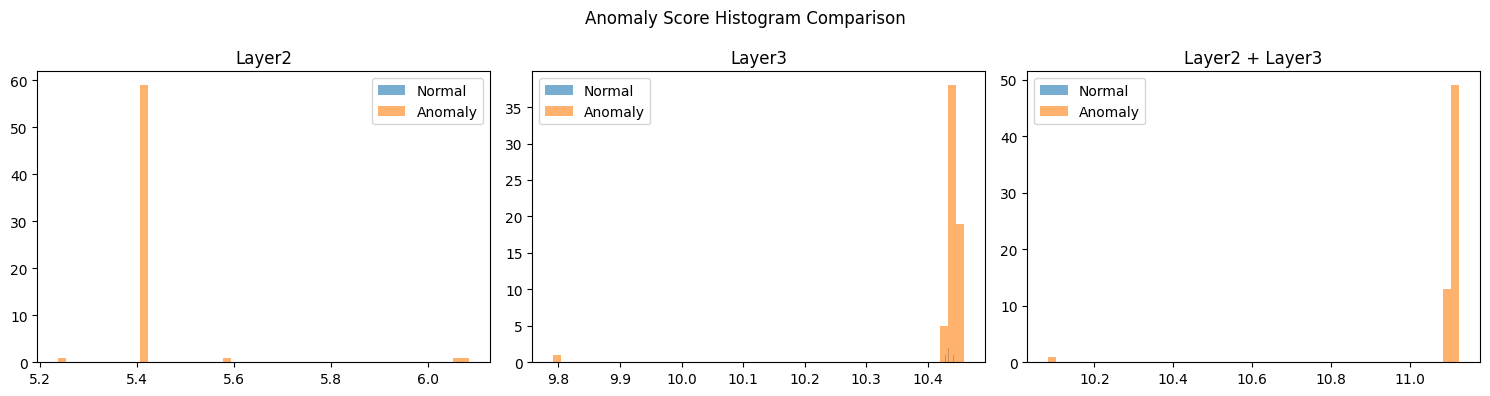

In [27]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(scores_l2[labels==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores_l2[labels==1], bins=50, alpha=0.6, label="Anomaly")
plt.title("Layer2")
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(scores_l3[labels==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores_l3[labels==1], bins=50, alpha=0.6, label="Anomaly")
plt.title("Layer3")
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(scores_l23[labels==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores_l23[labels==1], bins=50, alpha=0.6, label="Anomaly")
plt.title("Layer2 + Layer3")
plt.legend()

plt.suptitle("Anomaly Score Histogram Comparison")
plt.tight_layout()
plt.show()


In [28]:
from torchvision import models

model = models.resnet34(pretrained=True)
model.eval().to(device)
print("Using backbone: ResNet34")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using backbone: ResNet34


In [29]:
features = []

def hook(module, input, output):
    features.append(output)

model.layer3.register_forward_hook(hook)


In [30]:
memory_bank = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        features.clear()
        _ = model(x)

        feat = features[0]
        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1)
        memory_bank.append(feat.cpu().numpy())

memory_bank = np.concatenate(memory_bank, axis=0)
print("ResNet34 memory bank shape:", memory_bank.shape)


ResNet34 memory bank shape: (209, 256)


In [31]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=1)
nn_model.fit(memory_bank)


NearestNeighbors(n_neighbors=1)

In [32]:
scores = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        features.clear()
        _ = model(x)

        feat = features[0]
        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1).cpu().numpy()

        dist, _ = nn_model.kneighbors(feat)
        scores.append(dist[0][0])
        labels.append(y.item())

scores = np.array(scores)
labels = np.array(labels)


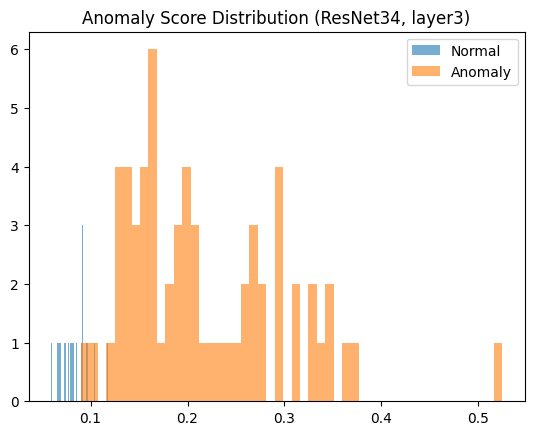

In [33]:
import matplotlib.pyplot as plt

plt.hist(scores[labels == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[labels == 1], bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.title("Anomaly Score Distribution (ResNet34, layer3)")
plt.show()


In [34]:
def register_hooks(model, layer_names, features_dict):
    hooks = []
    for name in layer_names:
        layer = getattr(model, name)
        hooks.append(
            layer.register_forward_hook(
                lambda m, i, o, n=name: features_dict.__setitem__(n, o)
            )
        )
    return hooks


In [35]:
from torchvision import models

model18 = models.resnet18(pretrained=True)
model18.eval().to(device)

features18 = {}
hooks18 = register_hooks(model18, ["layer2", "layer3"], features18)

print("ResNet18 layer2+3 hooks registered")


ResNet18 layer2+3 hooks registered


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
memory_bank18_l23 = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        features18.clear()
        _ = model18(x)

        f2 = features18["layer2"]
        f3 = features18["layer3"]

        # spatial size 맞추기
        f2 = F.adaptive_avg_pool2d(f2, f3.shape[-2:])
        feat = torch.cat([f2, f3], dim=1)

        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1)

        memory_bank18_l23.append(feat.cpu().numpy())

memory_bank18_l23 = np.concatenate(memory_bank18_l23, axis=0)
print("ResNet18 layer2+3 memory bank:", memory_bank18_l23.shape)


ResNet18 layer2+3 memory bank: (209, 384)


In [37]:
nn18_l23 = NearestNeighbors(n_neighbors=1)
nn18_l23.fit(memory_bank18_l23)


NearestNeighbors(n_neighbors=1)

In [38]:
scores18_l23 = []
labels18_l23 = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        features18.clear()
        _ = model18(x)

        f2 = features18["layer2"]
        f3 = features18["layer3"]

        f2 = F.adaptive_avg_pool2d(f2, f3.shape[-2:])
        feat = torch.cat([f2, f3], dim=1)

        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1).cpu().numpy()

        dist, _ = nn18_l23.kneighbors(feat)
        scores18_l23.append(dist[0][0])
        labels18_l23.append(y.item())

scores18_l23 = np.array(scores18_l23)
labels18_l23 = np.array(labels18_l23)


In [39]:
model34 = models.resnet34(pretrained=True)
model34.eval().to(device)

features34 = {}
hooks34 = register_hooks(model34, ["layer2", "layer3"], features34)

print("ResNet34 layer2+3 hooks registered")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet34 layer2+3 hooks registered


In [40]:
memory_bank34_l23 = []

with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        features34.clear()
        _ = model34(x)

        f2 = features34["layer2"]
        f3 = features34["layer3"]

        f2 = F.adaptive_avg_pool2d(f2, f3.shape[-2:])
        feat = torch.cat([f2, f3], dim=1)

        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1)

        memory_bank34_l23.append(feat.cpu().numpy())

memory_bank34_l23 = np.concatenate(memory_bank34_l23, axis=0)
print("ResNet34 layer2+3 memory bank:", memory_bank34_l23.shape)


ResNet34 layer2+3 memory bank: (209, 384)


In [41]:
nn34_l23 = NearestNeighbors(n_neighbors=1)
nn34_l23.fit(memory_bank34_l23)


NearestNeighbors(n_neighbors=1)

In [42]:
scores34_l23 = []
labels34_l23 = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        features34.clear()
        _ = model34(x)

        f2 = features34["layer2"]
        f3 = features34["layer3"]

        f2 = F.adaptive_avg_pool2d(f2, f3.shape[-2:])
        feat = torch.cat([f2, f3], dim=1)

        feat = F.adaptive_avg_pool2d(feat, (1, 1))
        feat = feat.view(feat.size(0), -1).cpu().numpy()

        dist, _ = nn34_l23.kneighbors(feat)
        scores34_l23.append(dist[0][0])
        labels34_l23.append(y.item())

scores34_l23 = np.array(scores34_l23)
labels34_l23 = np.array(labels34_l23)


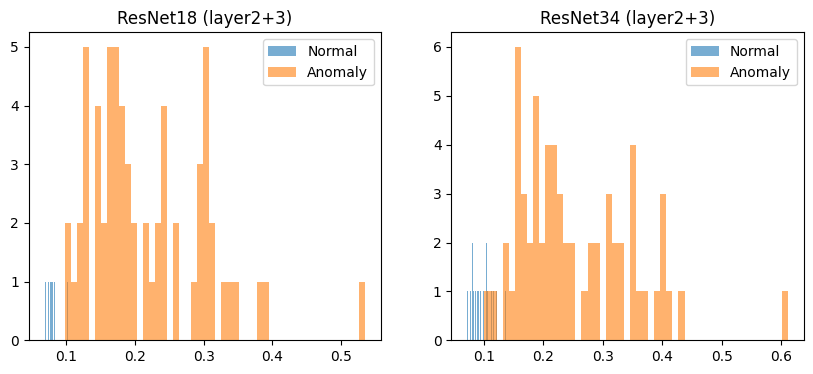

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(scores18_l23[labels18_l23==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores18_l23[labels18_l23==1], bins=50, alpha=0.6, label="Anomaly")
plt.title("ResNet18 (layer2+3)")
plt.legend()

plt.subplot(1,2,2)
plt.hist(scores34_l23[labels34_l23==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores34_l23[labels34_l23==1], bins=50, alpha=0.6, label="Anomaly")
plt.title("ResNet34 (layer2+3)")
plt.legend()

plt.show()


In [44]:
# ===============================
# Grid Dataset
# ===============================

GRID_DIR = "/content/grid"  # MVTec grid 경로

grid_train_ds = MVTecDataset(GRID_DIR, split="train", transform=transform)
grid_test_ds  = MVTecDataset(GRID_DIR, split="test",  transform=transform)

grid_train_loader = DataLoader(grid_train_ds, batch_size=1, shuffle=False)
grid_test_loader  = DataLoader(grid_test_ds,  batch_size=1, shuffle=False)

print("Grid train:", len(grid_train_ds))
print("Grid test :", len(grid_test_ds))


Grid train: 264
Grid test : 78


In [45]:
# ===============================
# Model (reuse backbone)
# ===============================

model.eval()

grid_features = []

def grid_hook(module, input, output):
    grid_features.append(output)

handle = model.layer3.register_forward_hook(grid_hook)


In [46]:
# ===============================
# Memory Bank (Grid - Normal)
# ===============================

grid_memory_bank = []

with torch.no_grad():
    for x, _ in grid_train_loader:
        x = x.to(device)
        grid_features.clear()

        _ = model(x)

        feat = grid_features[0]                  # [1, C, H, W]
        feat = F.adaptive_avg_pool2d(feat, (1,1))
        feat = feat.view(feat.size(0), -1)       # [1, C]

        grid_memory_bank.append(feat.cpu().numpy())

grid_memory_bank = np.concatenate(grid_memory_bank, axis=0)
print("Grid memory bank shape:", grid_memory_bank.shape)


Grid memory bank shape: (264, 256)


In [47]:
from sklearn.neighbors import NearestNeighbors

grid_nn = NearestNeighbors(n_neighbors=1)
grid_nn.fit(grid_memory_bank)


NearestNeighbors(n_neighbors=1)

In [48]:
# ===============================
# Grid Test Scoring
# ===============================

grid_scores = []
grid_labels = []

with torch.no_grad():
    for x, y in grid_test_loader:
        x = x.to(device)
        grid_features.clear()

        _ = model(x)

        feat = grid_features[0]
        feat = F.adaptive_avg_pool2d(feat, (1,1))
        feat = feat.view(feat.size(0), -1).cpu().numpy()

        dist, _ = grid_nn.kneighbors(feat)

        grid_scores.append(dist[0][0])
        grid_labels.append(y.item())

grid_scores = np.array(grid_scores)
grid_labels = np.array(grid_labels)


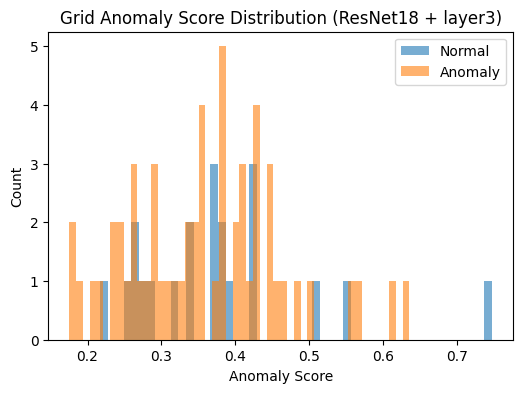

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(grid_scores[grid_labels == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(grid_scores[grid_labels == 1], bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.title("Grid Anomaly Score Distribution (ResNet18 + layer3)")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.show()


In [50]:
# hook 저장소
features_map = {}

def make_hook(name):
    def hook(module, input, output):
        features_map[name] = output
    return hook

# hook 등록
model.layer2.register_forward_hook(make_hook("layer2"))
model.layer3.register_forward_hook(make_hook("layer3"))

def build_memory_bank(dataloader, layer_name):
    bank = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            features_map.clear()
            _ = model(x)

            feat = features_map[layer_name]
            feat = F.adaptive_avg_pool2d(feat, (1, 1))
            feat = feat.view(feat.size(0), -1)
            bank.append(feat.cpu().numpy())
    return np.concatenate(bank, axis=0)

mem_l2 = build_memory_bank(train_loader, "layer2")
mem_l3 = build_memory_bank(train_loader, "layer3")
mem_l23 = np.concatenate([mem_l2, mem_l3], axis=1)

print(mem_l2.shape, mem_l3.shape, mem_l23.shape)


(209, 128) (209, 256) (209, 384)


In [51]:
nn_l2  = NearestNeighbors(n_neighbors=1).fit(mem_l2)
nn_l3  = NearestNeighbors(n_neighbors=1).fit(mem_l3)
nn_l23 = NearestNeighbors(n_neighbors=1).fit(mem_l23)


In [52]:
def collect_scores(dataloader, layer_names, nn_model):
    scores = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            amap = compute_anomaly_map(x, layer_names, nn_model, model)
            scores.append(amap.max())
            labels.append(y.item())

    return np.array(scores), np.array(labels)

scores_l2,  labels = collect_scores(test_loader, ["layer2"], nn_l2)
scores_l3,  _      = collect_scores(test_loader, ["layer3"], nn_l3)
scores_l23, _      = collect_scores(test_loader, ["layer2", "layer3"], nn_l23)


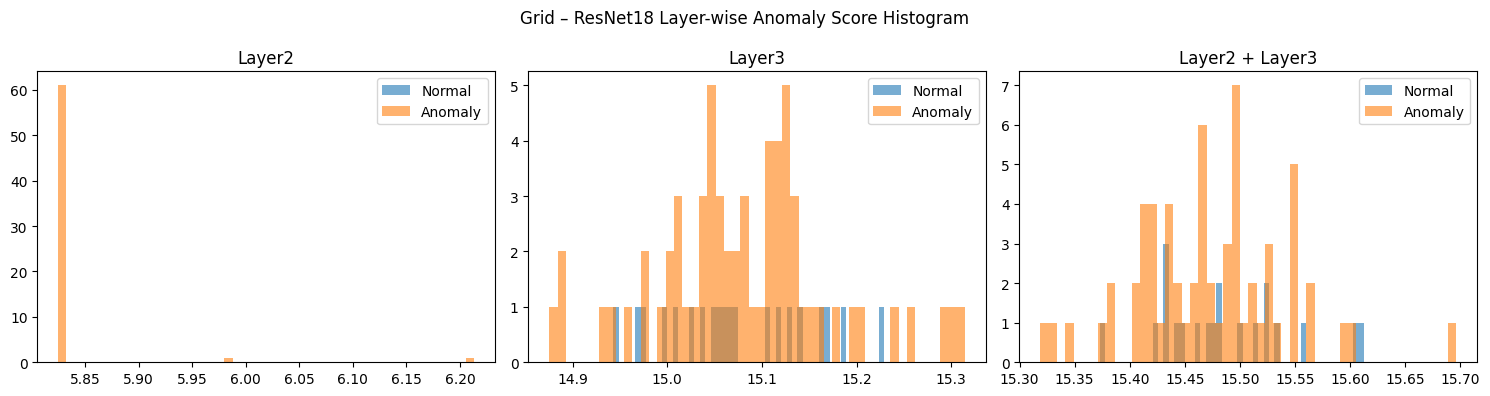

In [53]:
plt.figure(figsize=(15, 4))

for i, (scores, title) in enumerate([
    (scores_l2,  "Layer2"),
    (scores_l3,  "Layer3"),
    (scores_l23, "Layer2 + Layer3")
]):
    plt.subplot(1, 3, i+1)
    plt.hist(scores[labels == 0], bins=50, alpha=0.6, label="Normal")
    plt.hist(scores[labels == 1], bins=50, alpha=0.6, label="Anomaly")
    plt.title(title)
    plt.legend()

plt.suptitle("Grid – ResNet18 Layer-wise Anomaly Score Histogram")
plt.tight_layout()
plt.show()


In [54]:
idx = next(i for i, (_, y) in enumerate(test_ds) if y == 1)

x, y = test_ds[idx]
x = x.unsqueeze(0).to(device)


In [55]:
map_l2  = compute_anomaly_map(x, ["layer2"], nn_l2, model)
map_l3  = compute_anomaly_map(x, ["layer3"], nn_l3, model)
map_l23 = compute_anomaly_map(x, ["layer2", "layer3"], nn_l23, model)


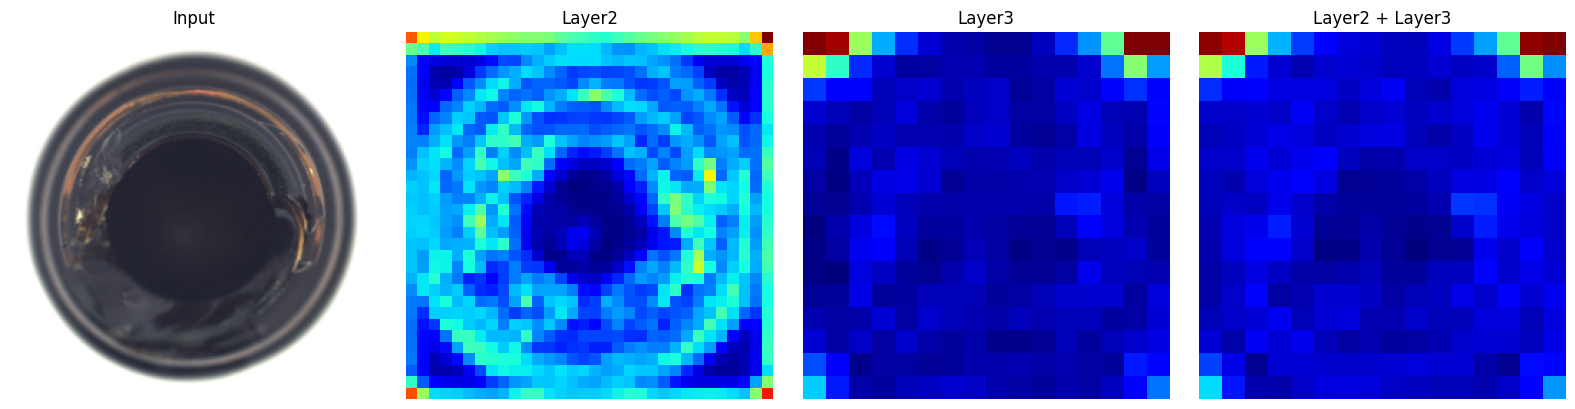

In [56]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(x[0].permute(1, 2, 0).cpu())
axs[0].set_title("Input")
axs[0].axis("off")

axs[1].imshow(map_l2, cmap="jet")
axs[1].set_title("Layer2")
axs[1].axis("off")

axs[2].imshow(map_l3, cmap="jet")
axs[2].set_title("Layer3")
axs[2].axis("off")

axs[3].imshow(map_l23, cmap="jet")
axs[3].set_title("Layer2 + Layer3")
axs[3].axis("off")

plt.tight_layout()
plt.show()


In [61]:
from torchvision.models import resnet18, resnet34
from torchvision.models import ResNet18_Weights, ResNet34_Weights

class ResNetBackbone(nn.Module):
    def __init__(self, name="resnet18"):
        super().__init__()

        if name == "resnet18":
            net = resnet18(weights=ResNet18_Weights.DEFAULT)
        elif name == "resnet34":
            net = resnet34(weights=ResNet34_Weights.DEFAULT)
        else:
            raise ValueError("Unsupported backbone")

        self.layer1 = nn.Sequential(
            net.conv1, net.bn1, net.relu, net.maxpool, net.layer1
        )
        self.layer2 = net.layer2
        self.layer3 = net.layer3

    def forward(self, x):
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        return {"layer2": f2, "layer3": f3}


In [62]:
class GridAnomalyModel(nn.Module):
    def __init__(self, backbone, use_layer="layer3"):
        super().__init__()
        self.backbone = backbone
        self.use_layer = use_layer

    def forward(self, x):
        feats = self.backbone(x)
        feat = feats[self.use_layer]

        # Grid-wise anomaly score (예시: L2 norm)
        score_map = torch.norm(feat, p=2, dim=1)
        image_score = score_map.mean(dim=[1, 2])

        return image_score, score_map


In [72]:
def plot_histogram(normal_scores, anomaly_scores, title="Histogram"):
    import matplotlib.pyplot as plt
    import numpy as np

    # GPU tensor이면 CPU로 옮기고 numpy 변환
    if isinstance(normal_scores, torch.Tensor):
        normal_scores = normal_scores.detach().cpu().numpy()
    if isinstance(anomaly_scores, torch.Tensor):
        anomaly_scores = anomaly_scores.detach().cpu().numpy()

    plt.figure(figsize=(6,4))
    plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal")
    plt.hist(anomaly_scores, bins=50, alpha=0.6, label="Anomaly")
    plt.legend()
    plt.title(title)
    plt.show()


In [70]:
def run_inference_grid(model, test_loader, device="cuda"):
    model.eval()

    normal_scores = []
    anomaly_scores = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.item()   # 0 or 1

            score = model(x)   # scalar anomaly score

            if y == 0:
                normal_scores.append(score)
            else:
                anomaly_scores.append(score)

    return normal_scores, anomaly_scores


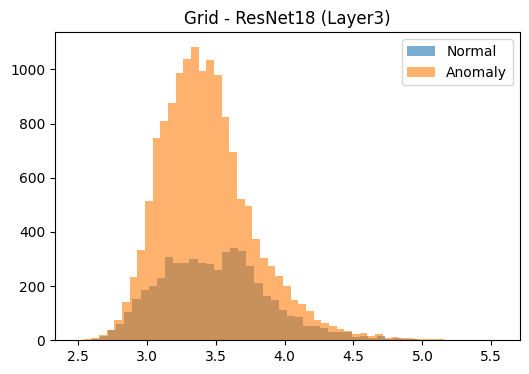

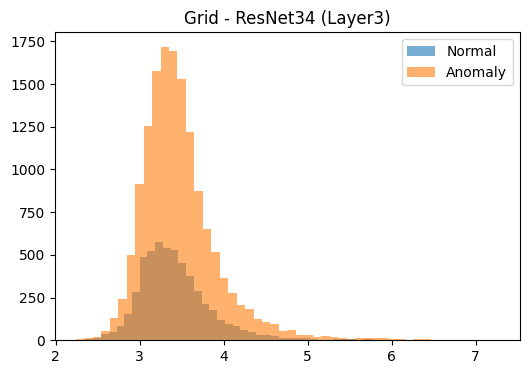

In [80]:
# Backbone 생성
backbone18 = ResNetBackbone("resnet18")
backbone34 = ResNetBackbone("resnet34")

# 모델 생성 + device 이동 (중요!!)
model18 = GridAnomalyModel(backbone18, use_layer="layer3").to(device)
model34 = GridAnomalyModel(backbone34, use_layer="layer3").to(device)

# inference
normal_scores_18, anomaly_scores_18 = run_inference_grid(
    model18, grid_test_loader, device=device
)
normal_scores_34, anomaly_scores_34 = run_inference_grid(
    model34, grid_test_loader, device=device
)

def tensor_list_to_numpy(x):
    """list/tuple 안에 있는 tensor를 모두 CPU numpy로 변환 후 flatten"""
    out = []
    for item in x:
        if torch.is_tensor(item):
            out.append(item.detach().cpu().numpy().reshape(-1))  # 1차원으로 변환
        elif isinstance(item, (list, tuple)):
            out.append(tensor_list_to_numpy(item))
        else:
            out.append(np.array(item))
    # 최종적으로 1차원 concatenate
    return np.concatenate(out)

# 변환
normal_scores_18 = tensor_list_to_numpy(normal_scores_18)
anomaly_scores_18 = tensor_list_to_numpy(anomaly_scores_18)
normal_scores_34 = tensor_list_to_numpy(normal_scores_34)
anomaly_scores_34 = tensor_list_to_numpy(anomaly_scores_34)

# 히스토그램
plot_histogram(normal_scores_18, anomaly_scores_18, "Grid - ResNet18 (Layer3)")
plot_histogram(normal_scores_34, anomaly_scores_34, "Grid - ResNet34 (Layer3)")


In [84]:
def compare_anomaly_maps(map1, map2, title1="ResNet18 Layer3", title2="ResNet34 Layer3"):
    """
    map1, map2: [H, W] numpy 또는 torch tensor (device 상관 없음)
    """
    # tensor이면 cpu numpy로 변환
    if torch.is_tensor(map1):
        map1 = map1.detach().cpu().numpy()
    if torch.is_tensor(map2):
        map2 = map2.detach().cpu().numpy()

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(map1, cmap="jet")
    plt.colorbar()
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(map2, cmap="jet")
    plt.colorbar()
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# layer별 feature 저장
features_map = {}

def make_hook(name):
    def hook(module, input, output):
        features_map[name] = output
    return hook

model18.backbone.layer3.register_forward_hook(make_hook("layer3"))
model34.backbone.layer3.register_forward_hook(make_hook("layer3"))

def build_memory_bank(dataloader, model, layer_name):
    bank = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            features_map.clear()
            _ = model(x)
            feat = features_map[layer_name]   # [1, C, H, W]
            feat = F.adaptive_avg_pool2d(feat, (1, 1))
            feat = feat.view(feat.size(0), -1)
            bank.append(feat.cpu().numpy())
    return np.concatenate(bank, axis=0)

# grid train_loader 기준 memory bank
mem_l3_18 = build_memory_bank(grid_train_loader, model18, "layer3")
mem_l3_34 = build_memory_bank(grid_train_loader, model34, "layer3")

# NearestNeighbors 생성
nn_l3_18 = NearestNeighbors(n_neighbors=1).fit(mem_l3_18)
nn_l3_34 = NearestNeighbors(n_neighbors=1).fit(mem_l3_34)


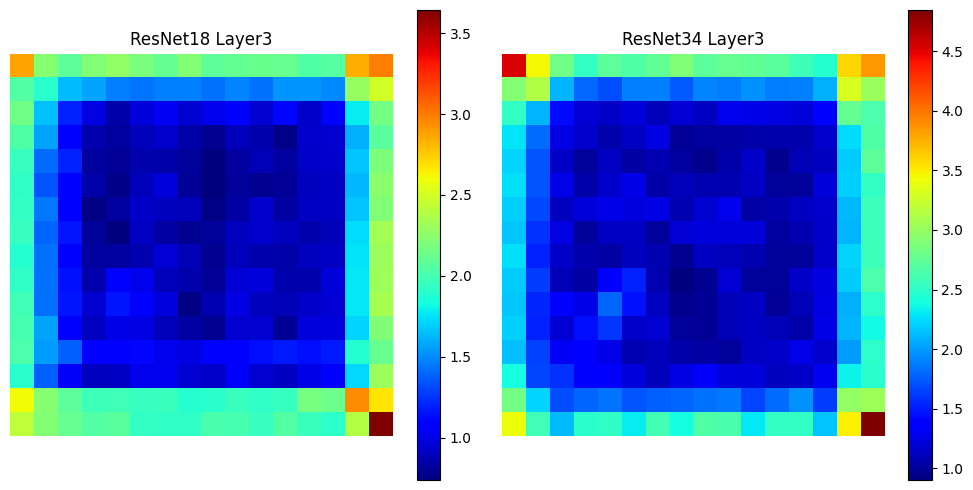

In [86]:
# 비교할 이미지 선택
idx = 0
x, y = grid_test_ds[idx]
x = x.unsqueeze(0).to(device)

# anomaly map 계산 (backbone.layer3로 접근)
map_r18_l3 = compute_anomaly_map(x, ["backbone.layer3"], nn_l3_18, model18)
map_r34_l3 = compute_anomaly_map(x, ["backbone.layer3"], nn_l3_34, model34)


# 시각화
compare_anomaly_maps(map_r18_l3, map_r34_l3)
